## Mean-Variance Portfolio Optimization (Markowitz / LQ Framework)

The multi-period MV problem is:

$$\max_{\{u_t\}} \; \mathbb{E}[x_T] - \phi \, \text{Var}(x_T)$$

subject to the wealth dynamics. The analytical solution takes the linear feedback form $u_t^*(x_t) = \alpha_t x_t + \beta_t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(24)

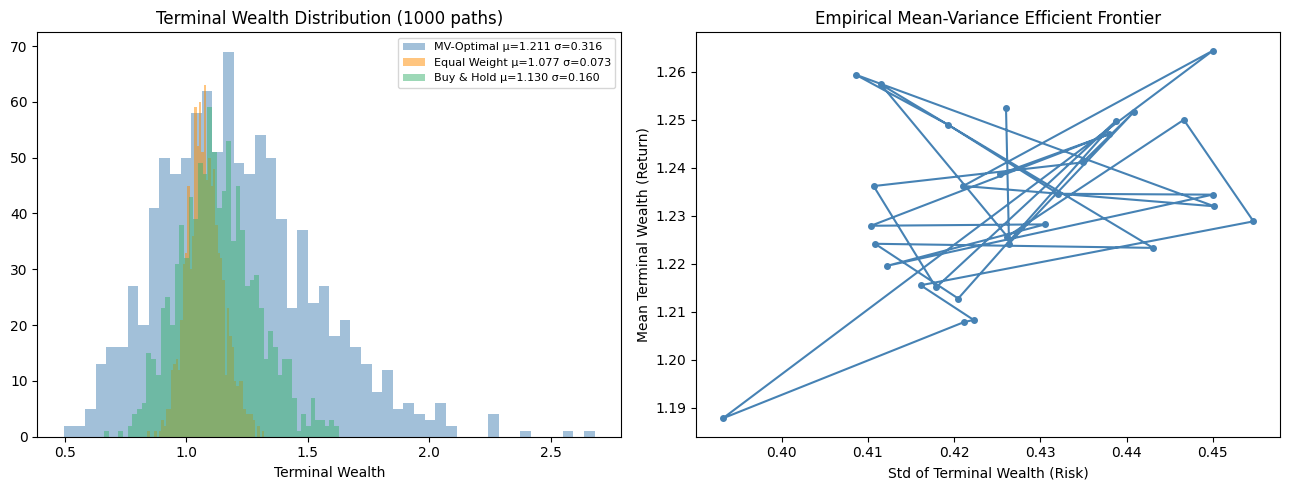

Sharpe - MV: 0.666, Equal: 1.050, Buy&Hold: 0.816


In [2]:
class MeanVariancePortfolio:
    """
    Multi-period Mean-Variance Portfolio Optimization
    Implements the Li & Ng (2000) analytical solution
    
    Two assets: risky (expected return mu, std sigma) + risk-free (return r_f)
    """
    def __init__(self, T=12, mu=0.01, sigma=0.05, r_f=0.002, phi=2.0, x0=1.0):
        self.T, self.mu, self.sigma = T, mu, sigma
        self.r_f, self.phi, self.x0 = r_f, phi, x0

    def analytical_solution(self):
        """
        Compute the analytical optimal policy parameters alpha_t, beta_t
        """
        T, mu, sigma, r_f, phi = self.T, self.mu, self.sigma, self.r_f, self.phi
        excess_return = mu - r_f
        sharpe_sq = (excess_return / sigma) ** 2

        # Backward induction to find policy parameters
        alpha = np.zeros(T)
        beta  = np.zeros(T)

        # At each period: optimal investment in risky asset
        # u_t* = alpha_t * x_t + beta_t
        for t in range(T-1, -1, -1):
            remaining = T - t
            # Fraction of wealth to invest in risky asset
            # (simplified 2-asset case, closed-form from LQ embedding)
            invest_frac = excess_return / (sigma**2 + excess_return**2) * \
                          (1 + sharpe_sq)**(remaining - 1)
            alpha[t] = invest_frac
            beta[t]  = 0.0  # zero in simple i.i.d. case

        return alpha, beta

    def simulate(self, strategy='mv', n_paths=1000):
        """
        Simulate terminal wealth under MV-optimal, equal-weight, or buy-and-hold strategies
        """
        alpha, beta = self.analytical_solution()
        T, mu, sigma, r_f, phi, x0 = self.T, self.mu, self.sigma, self.r_f, self.phi, self.x0

        terminal_wealth = []
        for _ in range(n_paths):
            x = x0
            for t in range(T):
                e_risky = 1 + r_f + (mu - r_f) + sigma * np.random.randn()
                e_riskfree = 1 + r_f

                if strategy == 'mv':
                    u = alpha[t] * x + beta[t]  # Optimal MV allocation
                elif strategy == 'equal':
                    u = 0.5 * x               # 50/50 split each period
                else:  # buy-and-hold risky
                    u = x

                u = np.clip(u, -2*x, 2*x)   # No leverage beyond 2x for stability
                x = u * e_risky + (x - u) * e_riskfree

            terminal_wealth.append(x)

        return np.array(terminal_wealth)


mv = MeanVariancePortfolio(T=12, mu=0.01, sigma=0.04, r_f=0.002, phi=2.0)

W_mv = mv.simulate('mv')
W_eq = mv.simulate('equal')
W_hold = mv.simulate('hold')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Terminal wealth distributions
for W, label, color in [
    (W_mv, 'MV-Optimal', 'steelblue'),
    (W_eq, 'Equal Weight', 'darkorange'),
    (W_hold, 'Buy & Hold', 'mediumseagreen'),
]:
    axes[0].hist(W, bins=50, alpha=0.5, label=f'{label} μ={W.mean():.3f} σ={W.std():.3f}', color=color)

axes[0].set_xlabel('Terminal Wealth')
axes[0].set_title('Terminal Wealth Distribution (1000 paths)')
axes[0].legend(fontsize=8)

# Mean-Variance efficient frontier
phi_vals = np.logspace(-1, 2, 30)
means, vars_ = [], []
for phi_v in phi_vals:
    m = MeanVariancePortfolio(phi=phi_v)
    W = m.simulate('mv', n_paths=500)
    means.append(W.mean())
    vars_.append(W.std())

axes[1].plot(vars_, means, '-o', color='steelblue', markersize=4)
axes[1].set_xlabel('Std of Terminal Wealth (Risk)')
axes[1].set_ylabel('Mean Terminal Wealth (Return)')
axes[1].set_title('Empirical Mean-Variance Efficient Frontier')

plt.tight_layout()
plt.show()

def sharpe(W): return (W.mean() - 1.0) / W.std() if W.std() > 0 else 0
print(f"Sharpe - MV: {sharpe(W_mv):.3f}, Equal: {sharpe(W_eq):.3f}, Buy&Hold: {sharpe(W_hold):.3f}")